In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from sklearn.decomposition import PCA

In [5]:
# Load Dataset Directly from GitHub
url = "https://raw.githubusercontent.com/Mehedi752/AI-ML-Lab/refs/heads/main/SVM/dataset/data.csv"

df = pd.read_csv(url)

# View First 5 Rows
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [7]:
# Dataset Exploration

# 1.Shape of Dataset
print("Shape of Dataset:")
print(df.shape)

# 2.Display 5 Random Samples
print("5 Random Samples:")
print(df.sample(5))

# 3.Dataset Information
print("Dataset Info:")
df.info()

# 4.Statistical Summary
print("Statistical Summary:")
print(df.describe())

# 5.Number of unique values in each column.
print("Number of Unique Values in Each Column:")
print(df.nunique())

# 6.Check Missing Values
print("Missing Values:")
print(df.isnull().sum())

# 7.Check Duplicate Rows
print("Duplicate Rows:")
print(df.duplicated().sum())

# 8.Memory Usage
print("Memory Usage:")
print(df.memory_usage())

# 9.Check Skewness
print("Skewness:")
print(df.skew(numeric_only=True))


Shape of Dataset:
(569, 33)
5 Random Samples:
          id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
485   913063         B        12.45         16.41           82.85      476.7   
363  9010872         B        16.50         18.29          106.60      838.1   
395   903811         B        14.06         17.18           89.75      609.1   
144   869254         B        10.75         14.97           68.26      355.3   
565   926682         M        20.13         28.25          131.20     1261.0   

     smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
485          0.09514           0.15110         0.15440             0.048460   
363          0.09686           0.08468         0.05862             0.048350   
395          0.08045           0.05361         0.02681             0.032510   
144          0.07793           0.05139         0.02251             0.007875   
565          0.09780           0.10340         0.14400             0.097910   

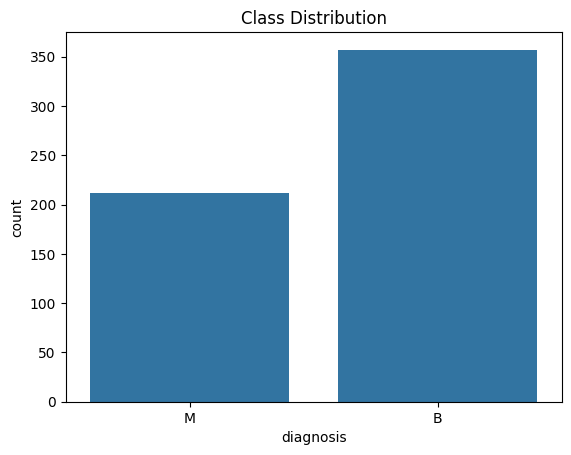

In [8]:
# Class Distribution
sns.countplot(x=df['diagnosis'])
plt.title("Class Distribution")
plt.show()

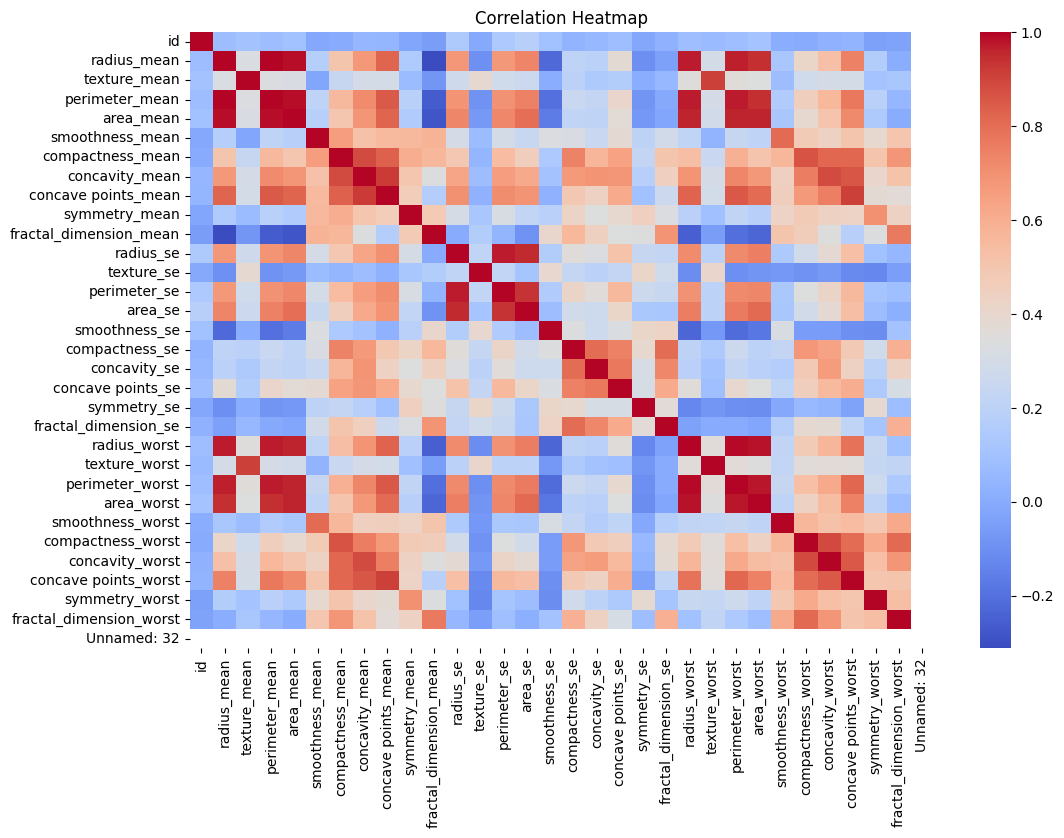

In [9]:
# Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

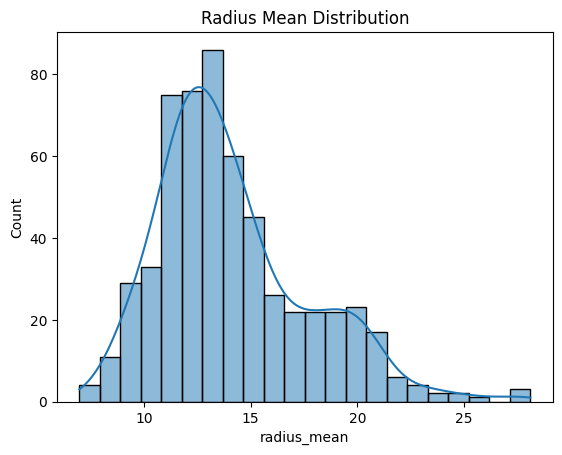

In [10]:
# Distribution Plot
sns.histplot(df['radius_mean'], kde=True)
plt.title("Radius Mean Distribution")
plt.show()

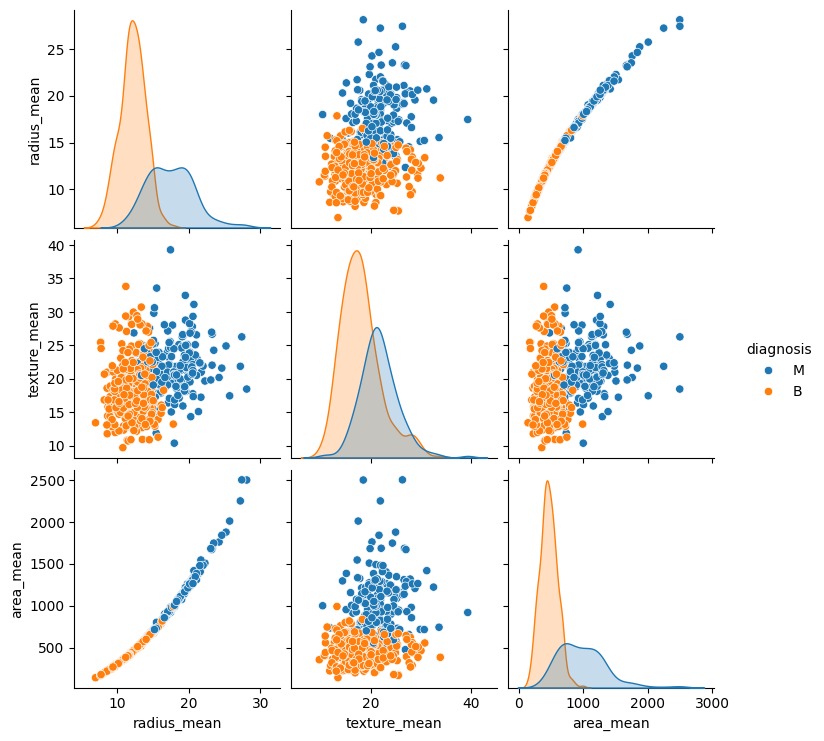

In [11]:
# Pair Plot
sns.pairplot(
    df[['radius_mean','texture_mean','area_mean','diagnosis']],
    hue='diagnosis'
)
plt.show()

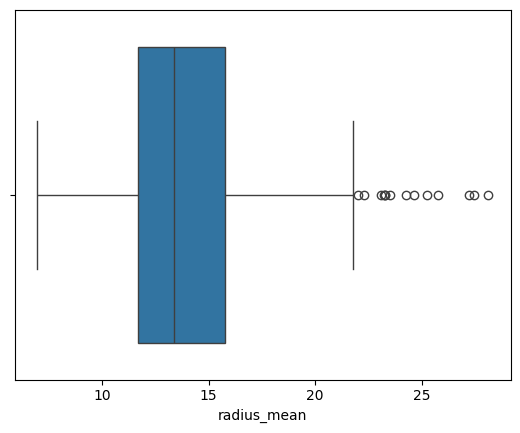

In [12]:
# Boxplot (Outliers)
sns.boxplot(x=df['radius_mean'])
plt.show()

In [13]:
# Data Cleaning
# 1.Handle Missing Values
df.fillna(df.mean(numeric_only=True), inplace=True)

# 2.Remove Duplicates
df.drop_duplicates(inplace=True)

In [14]:
# Encode CATEGORICAL FEATURES
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

In [19]:
# Feature Selection
X = df.drop(['id', 'diagnosis', 'Unnamed: 32'], axis=1)
y = df['diagnosis']

In [20]:
# Normalization / Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [22]:
# Split Data into Training and Testing Sets
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

In [26]:
# SVM Model Training
# Initial Model
svm_model = SVC(
    kernel='rbf',
    probability=True
)
svm_model.fit(X_train, y_train)

# Hyperparameter Tuning
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [1, 0.1, 0.01],
    'kernel': ['linear', 'rbf', 'poly'],
    'degree': [2, 3]
}

grid = GridSearchCV(
    SVC(probability=True),
    param_grid,
    refit=True,
    verbose=2,
    cv=3
)
grid.fit(X_train, y_train)

print(grid.best_params_)
best_model = grid.best_estimator_

Fitting 3 folds for each of 54 candidates, totalling 162 fits
[CV] END ............C=0.1, degree=2, gamma=1, kernel=linear; total time=   0.0s
[CV] END ............C=0.1, degree=2, gamma=1, kernel=linear; total time=   0.0s
[CV] END ............C=0.1, degree=2, gamma=1, kernel=linear; total time=   0.0s
[CV] END ...............C=0.1, degree=2, gamma=1, kernel=rbf; total time=   0.0s
[CV] END ...............C=0.1, degree=2, gamma=1, kernel=rbf; total time=   0.0s
[CV] END ...............C=0.1, degree=2, gamma=1, kernel=rbf; total time=   0.0s
[CV] END ..............C=0.1, degree=2, gamma=1, kernel=poly; total time=   0.0s
[CV] END ..............C=0.1, degree=2, gamma=1, kernel=poly; total time=   0.0s
[CV] END ..............C=0.1, degree=2, gamma=1, kernel=poly; total time=   0.0s
[CV] END ..........C=0.1, degree=2, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ..........C=0.1, degree=2, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ..........C=0.1, degree=2, gamma=0.1, 

In [27]:
# Model Predictions
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

In [28]:
# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("AUC:", auc)

Accuracy: 0.9883720930232558
Precision: 0.9629629629629629
Recall: 1.0
F1 Score: 0.9811320754716981
AUC: 0.9993589743589744


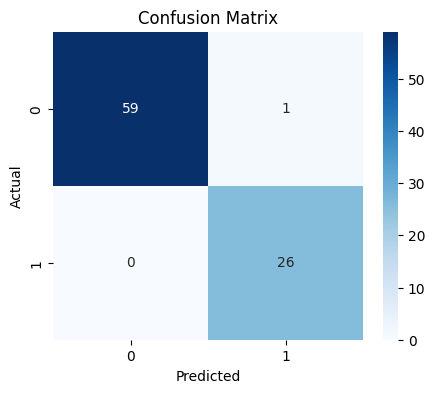

In [29]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

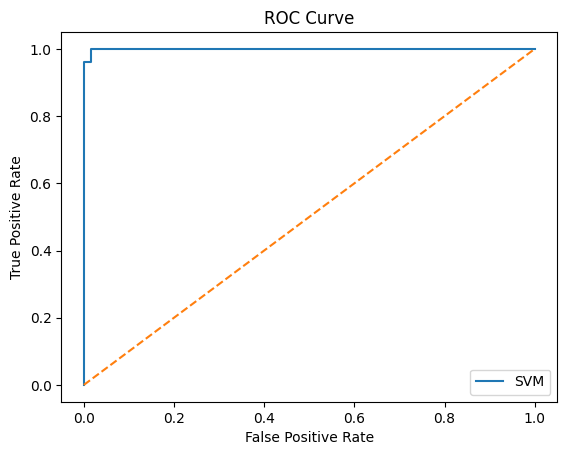

In [30]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label='SVM')

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [33]:
# Sample Predictions
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Probability': y_prob
})
results.head(10)

,Actual,Predicted,Probability
0,0,0,0.000020
1,0,0,0.015355
2,0,0,0.000538
3,1,1,0.996564
4,0,0,0.000266
5,0,0,0.000142
6,1,1,0.992465
7,0,0,0.021959
8,0,0,0.043749
9,0,0,0.143763


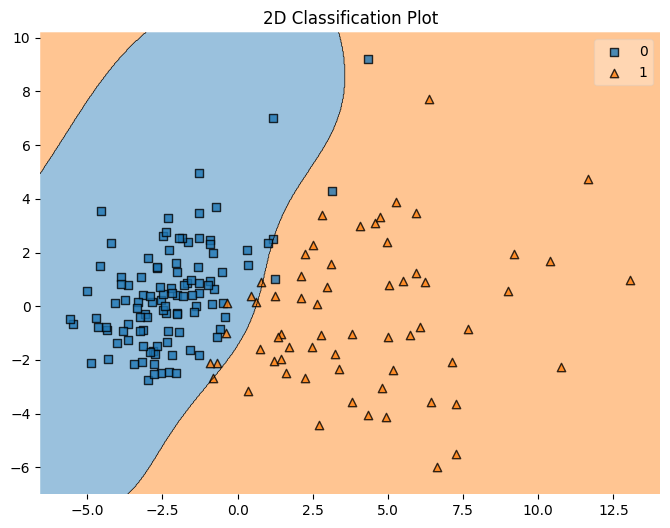

In [36]:
# 2D Classification Plot
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y,
    test_size=0.3,
    random_state=42
)

svm_2d = SVC(kernel='rbf')
svm_2d.fit(X_train_pca, y_train_pca)

from mlxtend.plotting import plot_decision_regions

plt.figure(figsize=(8,6))
plot_decision_regions(
    X_test_pca,
    y_test_pca.values,
    clf=svm_2d
)
plt.title("2D Classification Plot")

plt.show()

In [37]:
#Conclusion
#The Support Vector Machine (SVM) model was successfully implemented on the Breast Cancer Classification dataset. Exploratory Data Analysis (EDA)
#was conducted to understand the dataset structure, analyze feature relationships, detect missing values, and identify outliers.